In [1]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
get_db_summary()

---------------------------------------------
No. Tickers : 29
No. Rows    : 38,863
---------------------------------------------


,Ticker,rows,start_date,end_date
0,ACB,1342,2021-01-04,2026-05-27
1,BID,1342,2021-01-04,2026-05-27
2,CTG,1342,2021-01-04,2026-05-27
3,DGC,1342,2021-01-04,2026-05-27
4,FPT,1342,2021-01-04,2026-05-27
5,GAS,1342,2021-01-04,2026-05-27
6,GVR,1342,2021-01-04,2026-05-27
7,HDB,1342,2021-01-04,2026-05-27
8,HPG,1342,2021-01-04,2026-05-27
9,LPB,1342,2021-01-04,2026-05-27


BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (NGUỒN: KBS)

1️⃣ KIỂM TRA GIÁ TRỊ RỖNG / ZERO:
 ➔ Số dòng có giá Close <= 0: 0 dòng ✅
 ➔ Số dòng có Volume = 0    : 0 dòng (Thường là các ngày ngưng giao dịch)

2️⃣ KIỂM TRA LOGIC NẾN NHẬT (OHLC):
 ➔ Số dòng có giá High/Low phi logic: 0 dòng ✅

3️⃣ KIỂM TRA SỰ ĐỒNG ĐỀU GIỮA CÁC MÃ TÀI SẢN:
 ➔ Tất cả 30 mã đều có số lượng dữ liệu đồng đều. ✅

4️⃣ KIỂM TRA OUTLIER (Biến động > 8%/ngày):
 ❌ CẢNH BÁO: Phát hiện 13 điểm dữ liệu nghi ngờ sai lệch biên độ giá HOSE.


,Ticker,Date,Close,Daily_Return
20141,SHB,2021-01-19,6.65,-0.091530
20148,SHB,2021-01-28,5.55,-0.096091
20151,SHB,2021-02-02,5.78,0.088512
20184,SHB,2021-03-26,7.67,0.095714
20185,SHB,2021-03-29,8.42,0.097784
20186,SHB,2021-03-30,9.24,0.097387
20187,SHB,2021-03-31,10.11,0.094156
20190,SHB,2021-04-05,9.56,-0.099812
20215,SHB,2021-05-13,11.25,0.096491
20216,SHB,2021-05-14,12.38,0.100444


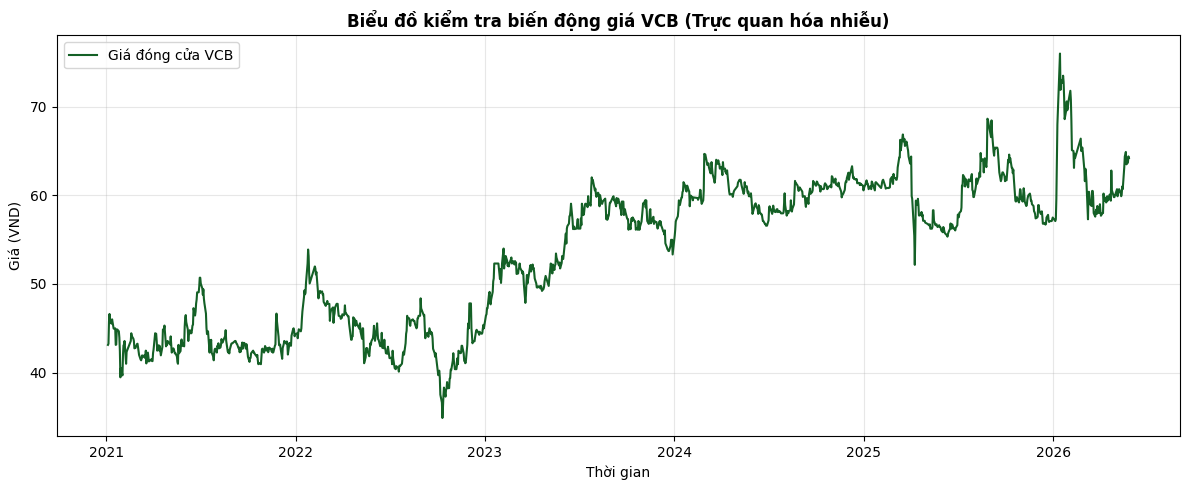

In [2]:
import sys
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Trỏ đường dẫn và kết nối Database
sys.path.append(os.path.abspath('./src'))
from data_loader import DB_PATH, get_connection

conn = get_connection()
df = pd.read_sql_query("SELECT * FROM Stock_Prices", conn)
conn.close()

df['Date'] = pd.to_datetime(df['Date'])

print("="*50)
print("BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (NGUỒN: KBS)")
print("="*50)

# 2. Kiểm tra dữ liệu rỗng hoặc bằng 0
print("\n1️⃣ KIỂM TRA GIÁ TRỊ RỖNG / ZERO:")
zero_close = df[df['Close'] <= 0]
zero_volume = df[df['Volume'] == 0]
print(f" ➔ Số dòng có giá Close <= 0: {len(zero_close)} dòng", "✅" if len(zero_close) == 0 else "❌")
print(f" ➔ Số dòng có Volume = 0    : {len(zero_volume)} dòng (Thường là các ngày ngưng giao dịch)")

# 3. Kiểm tra logic OHLC (Open, High, Low, Close)
print("\n2️⃣ KIỂM TRA LOGIC NẾN NHẬT (OHLC):")
invalid_ohlc = df[(df['High'] < df['Low']) | (df['High'] < df['Close']) | (df['Low'] > df['Close'])]
print(f" ➔ Số dòng có giá High/Low phi logic: {len(invalid_ohlc)} dòng", "✅" if len(invalid_ohlc) == 0 else "❌")
if len(invalid_ohlc) > 0:
    display(invalid_ohlc.head())

# 4. Kiểm tra độ đồng đều của 30 mã
print("\n3️⃣ KIỂM TRA SỰ ĐỒNG ĐỀU GIỮA CÁC MÃ TÀI SẢN:")
summary = df.groupby('Ticker').agg(
    Total_Rows=('Date', 'count'),
    Min_Date=('Date', 'min'),
    Max_Date=('Date', 'max')
)
median_rows = summary['Total_Rows'].median()
summary['Hụt_so_với_trung_bình'] = median_rows - summary['Total_Rows']

# Lọc ra các mã bị hụt quá 5% số dòng so với trung bình chung
missing_data_tickers = summary[summary['Hụt_so_với_trung_bình'] > (median_rows * 0.05)]
if len(missing_data_tickers) > 0:
    print(" ⚠️ CẢNH BÁO: Các mã sau có lượng dữ liệu hụt bất thường so với mặt bằng chung:")
    display(missing_data_tickers)
else:
    print(" ➔ Tất cả 30 mã đều có số lượng dữ liệu đồng đều. ✅")

# 5. Kiểm tra Outlier (Lỗi nhân dữ liệu hoặc chưa điều chỉnh giá)
print("\n4️⃣ KIỂM TRA OUTLIER (Biến động > 8%/ngày):")
# Tính % thay đổi giá hàng ngày cho từng mã
df = df.sort_values(['Ticker', 'Date'])
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

# Sàn HOSE biên độ 7%, nếu có ngày nào vọt > 8% (0.08) thì dữ liệu có vấn đề (vd: lỗi cổ tức)
outliers = df[(df['Daily_Return'] > 0.08) | (df['Daily_Return'] < -0.08)]
if len(outliers) > 0:
    print(f" ❌ CẢNH BÁO: Phát hiện {len(outliers)} điểm dữ liệu nghi ngờ sai lệch biên độ giá HOSE.")
    display(outliers[['Ticker', 'Date', 'Close', 'Daily_Return']].head(10))
else:
    print(" ➔ Không phát hiện biến động giá vượt trần/sàn bất hợp lý. Dữ liệu mượt mà. ✅")

# 6. Trực quan hóa kiểm tra mã đại diện 
ticker_test = 'VCB'
df_plot = df[df['Ticker'] == ticker_test]

plt.figure(figsize=(12, 5))
plt.plot(df_plot['Date'], df_plot['Close'], label=f'Giá đóng cửa {ticker_test}', color='#146026', linewidth=1.5)
plt.title(f'Biểu đồ kiểm tra biến động giá {ticker_test} (Trực quan hóa nhiễu)', fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VND)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
from data_loader import load_from_db
import pandas as pd

# load_from_db trả về single ticker DataFrame với cột Close
df_shb = load_from_db('SHB', start='2021-01-01', end='2021-06-30')
print("=== Giá SHB từ DB ===")
print(df_shb['2021-01-15':'2021-02-05'])

returns = df_shb['Close'].pct_change().dropna()
print("\n=== Return SHB tháng 1/2021 ===")
print(returns['2021-01-15':'2021-02-05'].round(4))

outliers = returns[returns.abs() > 0.08]
print(f"\nOutliers > 8%: {len(outliers)}")
print(outliers)

=== Giá SHB từ DB ===
            Open  High   Low  Close    Volume
Date                                         
2021-01-15  7.55  7.71  7.48   7.55  59202831
2021-01-18  7.67  7.67  7.28   7.32  37508242
2021-01-19  7.32  7.36  6.61   6.65  53114820
2021-01-20  6.69  7.00  6.06   6.96  43360480
2021-01-21  6.96  7.12  6.81   7.00  22062662
2021-01-22  7.00  7.04  6.77   6.85  22669983
2021-01-25  6.85  6.85  6.57   6.57  24078933
2021-01-26  6.57  6.61  5.98   6.45  44996014
2021-01-27  6.45  6.49  6.06   6.14  23195032
2021-01-28  6.06  6.10  5.55   5.55  24833988
2021-01-29  5.00  5.86  5.00   5.74  32327338
2021-02-01  5.70  5.82  5.31   5.31  19798552
2021-02-02  5.23  5.82  5.19   5.78  31635547
2021-02-03  5.78  6.22  5.78   6.10  26159418
2021-02-04  6.14  6.18  5.94   6.06  15714340
2021-02-05  6.06  6.33  5.98   6.33  29418304

=== Return SHB tháng 1/2021 ===
Date
2021-01-15    0.0053
2021-01-18   -0.0305
2021-01-19   -0.0915
2021-01-20    0.0466
2021-01-21    0.0057
2021-01